In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [9]:
from sklearn.model_selection import train_test_split

In [2]:
from sklearn.datasets import make_blobs

In [3]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
x

array([[ 5.14553822, -0.11357837],
       [-0.17882137,  9.02292108],
       [ 0.10772256,  5.90639891],
       ...,
       [ 5.44123361, -6.0588676 ],
       [ 5.0778142 ,  2.99946565],
       [ 4.37036808, -0.81310974]], shape=(1000, 2))

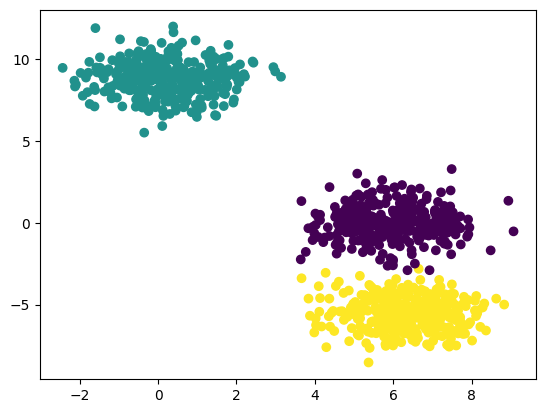

In [48]:
plt.scatter(x[:,0],x[0:,1],c=y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [11]:
x_t,x_test,y_t,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [26]:
x_ts=scaler.fit_transform(x_t)
x_tests=scaler.fit_transform(x_test)

In [27]:
from sklearn.cluster import KMeans

In [28]:
#elbow method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_ts)
    wcss.append(kmeans.inertia_)

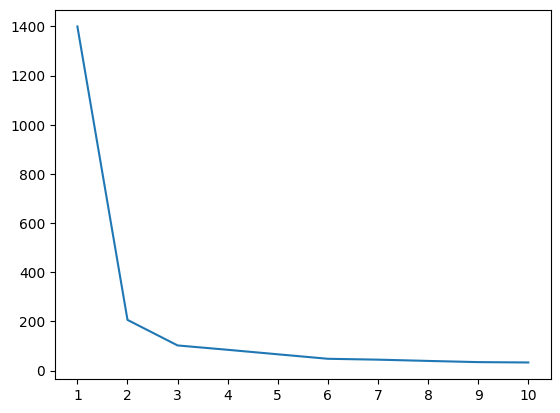

In [29]:
#plot elbow
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.show()

In [38]:
kmeans=KMeans(n_clusters=2,init="k-means++")

In [39]:
kmeans.fit_predict(x_ts)

array([1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,

In [40]:
y_pred=kmeans.predict(x_tests)

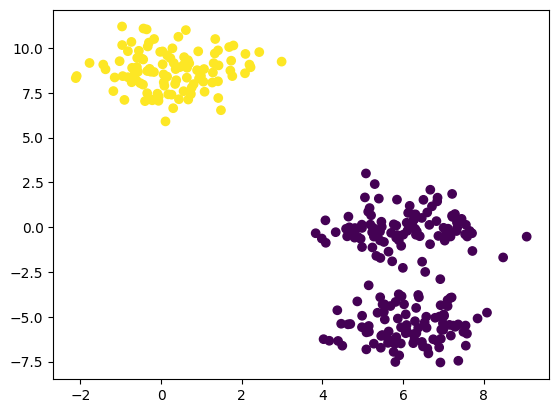

In [41]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [42]:
#validian the k val
#kneel locator
##silhoutee scoring
!pip install kneed


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction="decreasing")

In [37]:
kl.elbow

np.int64(2)

In [43]:
#silhoutte score 
from sklearn.metrics import silhouette_score

In [46]:
silhouette_coeff=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_ts)
    score=silhouette_score(x_ts,kmeans.labels_)
    silhouette_coeff.append(score)

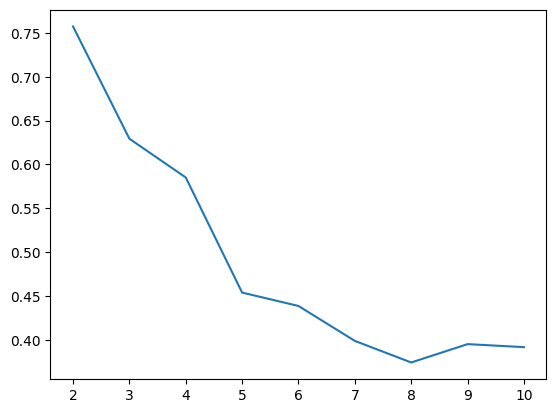

In [47]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.show()